<a href="https://colab.research.google.com/github/llShathaAlharbi/SDAIA-Computer-Vision-Program-/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 170M/170M [19:23<00:00, 147kB/s]


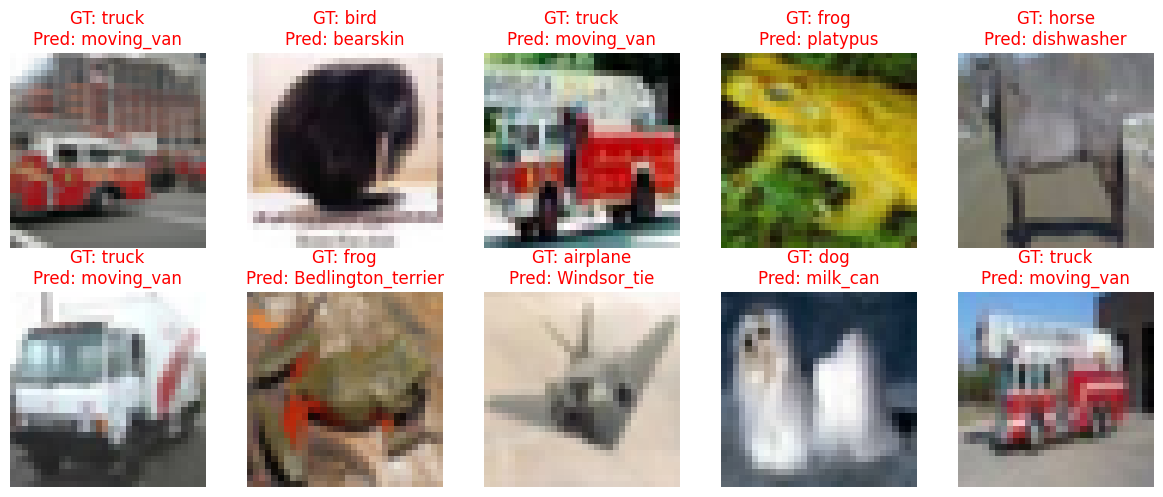

Part 1 Accuracy: 0/10 (0.0%)
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cifar10, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=

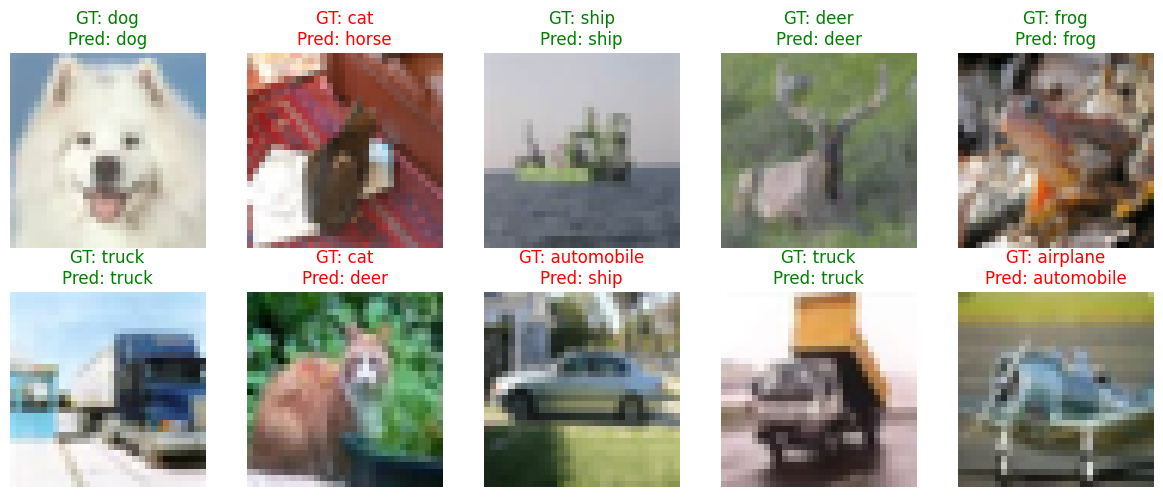

Part 2 Accuracy (10 samples): 6/10 (60.0%)


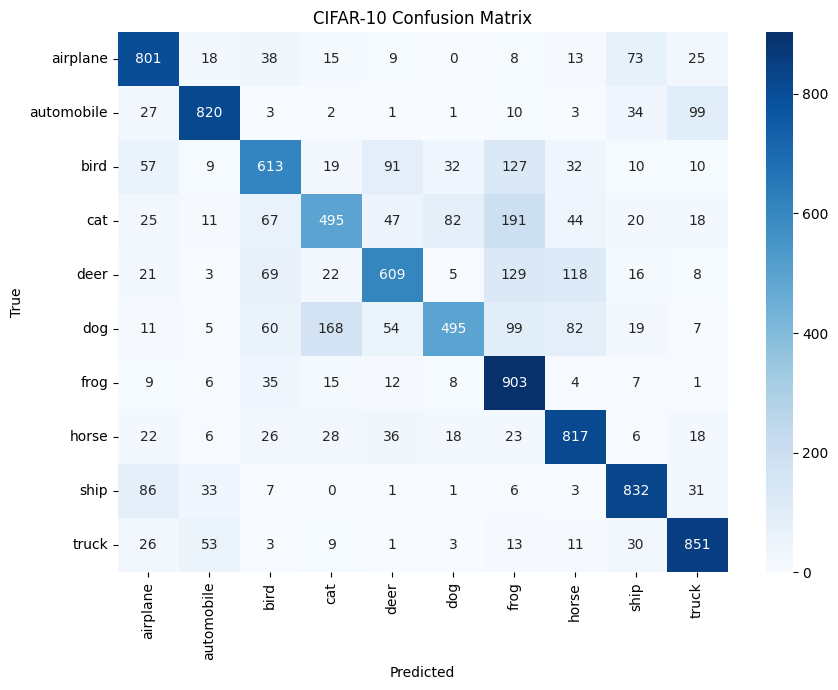

In [2]:
!pip install ultralytics torch torchvision matplotlib seaborn scikit-learn numpy -q
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from ultralytics import YOLO

device = 'cuda' if torch.cuda.is_available() else 'cpu'
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
transform = transforms.ToTensor()
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Part 1
pretrained_model = YOLO('yolov8n-cls.pt')
indices = np.random.choice(len(test_dataset), 10, replace=False)
correct = 0

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(indices):
    img_tensor, label = test_dataset[idx]
    pil_img = transforms.ToPILImage()(img_tensor)
    results = pretrained_model(pil_img, verbose=False)
    pred_class = results[0].names[results[0].probs.top1]
    gt_class = class_names[label]

    if pred_class == gt_class:
        correct += 1

    ax = axes[i // 5, i % 5]
    ax.imshow(np.transpose(img_tensor.numpy(), (1, 2, 0)))
    ax.set_title(f"GT: {gt_class}\nPred: {pred_class}", color='green' if pred_class == gt_class else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Part 1 Accuracy: {correct}/10 ({(correct/10)*100}%)")

# Part 2
model = YOLO('yolov8n-cls.pt')
model.train(data='cifar10', epochs=5, imgsz=32, batch=64, device=device)

indices_p2 = np.random.choice(len(test_dataset), 10, replace=False)
correct_p2 = 0

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(indices_p2):
    img_tensor, label = test_dataset[idx]
    pil_img = transforms.ToPILImage()(img_tensor)
    results = model(pil_img, verbose=False)
    pred_class = results[0].names[results[0].probs.top1]
    gt_class = class_names[label]

    if pred_class == gt_class:
        correct_p2 += 1

    ax = axes[i // 5, i % 5]
    ax.imshow(np.transpose(img_tensor.numpy(), (1, 2, 0)))
    ax.set_title(f"GT: {gt_class}\nPred: {pred_class}", color='green' if pred_class == gt_class else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Part 2 Accuracy (10 samples): {correct_p2}/10 ({(correct_p2/10)*100}%)")

y_true = []
y_pred = []

for i in range(len(test_dataset)):
    img_tensor, label = test_dataset[i]
    pil_img = transforms.ToPILImage()(img_tensor)
    results = model(pil_img, verbose=False)
    pred_class = results[0].names[results[0].probs.top1]

    y_true.append(class_names[label])
    y_pred.append(pred_class)

cm = confusion_matrix(y_true, y_pred, labels=class_names)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIFAR-10 Confusion Matrix')
plt.tight_layout()
plt.show()